In [2]:
import seaborn as sns
from sklearn.datasets import make_blobs

In [3]:
X,y = make_blobs(
    n_samples = 1000,
    n_features = 2,
    centers = 4,
    random_state = 42
)
    

<Axes: >

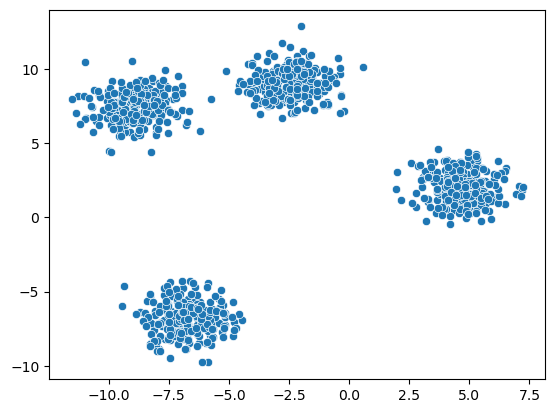

In [4]:
# visualize
sns.scatterplot(x = X[:,0],y = X[:,1])

In [5]:
from  sklearn.cluster import KMeans

In [6]:
# here we know the k value
k=4
Kmeans = KMeans(
    n_clusters = k,
    random_state = 42
)

In [7]:
labels = Kmeans.fit_predict(X)

<Axes: >

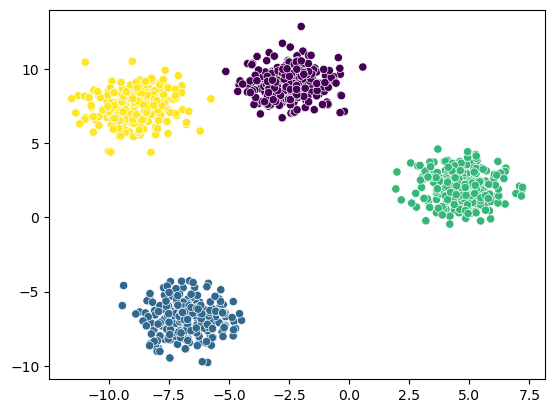

In [8]:
# visualize
sns.scatterplot(x = X[:,0],y = X[:,1], c=labels)

# choose our k value : elbow ,silhouette score


In [14]:
# Elbow method                  

wcss =[]
for k in range(1,21):
    Kmeans = KMeans(n_clusters = k)
    Kmeans.fit_predict(X)
    wcss.append(Kmeans.inertia_)
    

<Axes: >

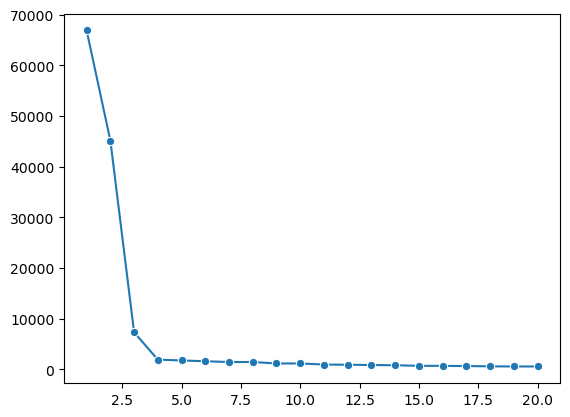

In [16]:
sns.lineplot(x=range(1,21),y=wcss,marker = 'o') 

In [17]:
# finding value automatick
!pip install kneed

In [18]:
from kneed import KneeLocator

In [20]:
knee = KneeLocator(range(1,21), wcss ,curve = "convex",direction = "decreasing")


In [21]:
print("optimal value of k = ",knee.elbow)

optimal value of k =  4


# silhouette_score

In [22]:
from sklearn.metrics import silhouette_score

In [24]:
ss =[]
for k in range(2,21):    # we start it from 2 beacuase 1 cluster doesnot make senses
    Kmeans = KMeans(n_clusters = k)
    labels = Kmeans.fit_predict(X)
    score = silhouette_score(X , labels)

    ss.append(score)

<Axes: >

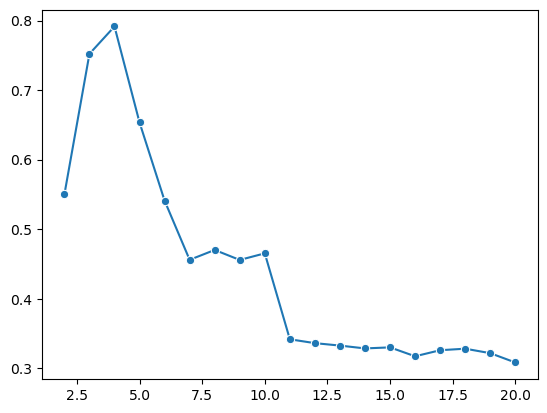

In [26]:
# plot = k $ ss
sns.lineplot(x = range(2,21), y = ss, marker = 'o')

In [27]:
# in above figure we notice that ss peak at 4 and the range bweteen (-1,1)